<a href="https://colab.research.google.com/github/rahiakela/deep-learning-research-and-practice/blob/main/neural-networks-from-scratch-in-python/04_calculating_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

To train a model, we tweak the weights and biases to improve the model’s accuracy and confidence.

To do this, we calculate how much error the model has. The loss function , also referred to as the cost function , is the
algorithm that quantifies how wrong a model is.

Loss is the measure of this metric. Since loss is
the model’s error, we ideally want it to be 0.

In [ ]:
!pip install nnfs

In [5]:
import numpy as np

import nnfs
from nnfs.datasets import spiral_data

import math
import matplotlib.pyplot as plt

## Dense Layer

In [ ]:
class DenseLayer:

  # Initialize weights and biases
  def __init__(self, n_inputs, n_neurons) -> None:
    # Note that we’re initializing weights to be (inputs, neurons), rather than ( neurons, inputs)
    self.weights = 0.01 * np.random.randn(n_inputs, n_neurons) # Gaussian distribution with a mean of 0 and a variance of 1
    self.bias = np.zeros((1, n_neurons))

  # Forward pass: Here, we pass data through a model from beginning to end
  def forward(self, inputs):
    # Calculate output values from inputs, weights and biases
    self.output = np.dot(inputs, self.weights) + self.bias

## ReLU Activation

In [ ]:
class ReLU():
  def forward(self, inputs):
    # Calculate output values from input
    self.output = np.maximum(0, inputs)

## Softmax Activation

In [ ]:
class Softmax:
  def forward(self, inputs):
    # Get unnormalized probabilities
    exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))

    # Normalize them for each sample
    probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
    self.output = probabilities

## Categorical Cross-Entropy Loss

Our model has a softmax activation function for the output layer, which means it’s outputting a probability distribution.

Categorical cross-entropy is explicitly used to compare
a “ground-truth” probability ($y$ or “targets”) and some predicted distribution ($\hat{y}$  or  “predictions”), so it makes sense to use cross-entropy here.

$$L_i = - \Sigma y_{i,j} log(\hat{y}_{i,j})$$

Once we start coding the solution, we’ll simplify it further to - log(correct_class_confidence).

$$L_i = - log(\hat{y}_{i,k})$$

- where $k$ is an index of "true" probability

In our case, we have a classification model that returns a probability distribution over all of the outputs.

Cross-entropy compares two probability distributions.

In [1]:
softmax_output = [0.7, 0.1, 0.2]

Which probability distribution do we intend to compare this to?

We have 3 class confidences in the above output, and let’s assume that the desired prediction is the first class (index 0, which is currently 0.7). If that’s the intended prediction, then the desired probability distribution is [1, 0, 0].

if we take a softmax output of [0.7, 0.1, 0.2] and targets of [1, 0, 0] , we can apply the calculations as follows:

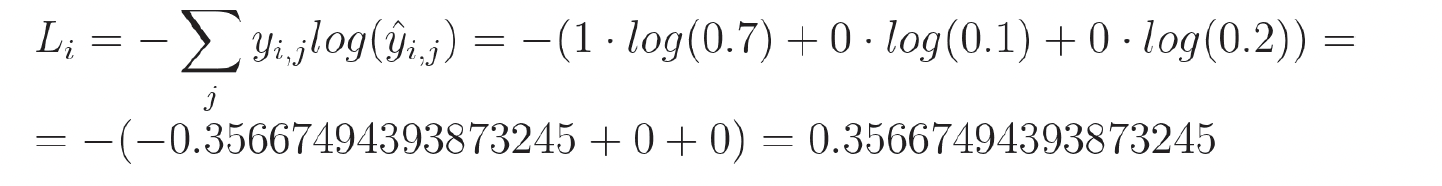

In [6]:
# An example output from the output layer of the neural network
softmax_output = [0.7, 0.1, 0.2]

# Ground truth
target_output = [1, 0, 0]

loss = - (math.log(softmax_output[0]) * target_output[0] +
          math.log(softmax_output[1]) * target_output[1] +
          math.log(softmax_output[2]) * target_output[2])

print(loss)

0.35667494393873245


In [7]:
math.log(0.70)

-0.35667494393873245

But, we know that anything multiplied by 0 is 0 and any number multiplied by 1 remains the same.

So, The same output then can be calculated with:

In [10]:
loss = -math.log(softmax_output[0])
print(loss)

0.35667494393873245


Log is short for logarithm and is defined as the solution for the x-term in an equation of the form $a^x = b$.

The logarithm with e as its base is referred to as
the natural logarithm; The natural log
represents the solution for the x-term in the equation $e^x = b$.

In [11]:
b = 5.2
print(np.log(b))

1.6486586255873816


In [12]:
# let's confirm it
print(math.e ** 1.6486586255873816)

5.199999999999999


Consider a scenario with a neural network that performs classification between three classes, and the neural network classifies in batches of three.

After running through the softmax activation function with a batch of 3 samples and 3 classes, the network’s output layer yields:

In [13]:
# Probabilities for 3 samples
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

## Neural Network

In [ ]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 3 output values
dense_layer1 = DenseLayer(2, 3)

# Create ReLU activation (to be used with Dense layer):
relu_activation = ReLU()

# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
dense_layer2 = DenseLayer(3, 3)

# Create Softmax activation (to be used with Dense layer):
softmax_activation = Softmax()

# Make a forward pass of our training data through this layer
dense_layer1.forward(X)

# Make a forward pass through ReLU activation function
# it takes the output of first dense layer here
relu_activation.forward(dense_layer1.output)

# Make a forward pass through second Dense layer
# it takes outputs of ReLU activation function of first layer as inputs
dense_layer2.forward(relu_activation.output)

# Make a forward pass through Softmax activation function
# it takes the output of second dense layer here
softmax_activation.forward(dense_layer2.output)

# Let's see output of the first few samples
print(softmax_activation.output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]]


In [ ]:
print(softmax_activation.output[:25])

[[0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333546 0.3333302  0.3333343 ]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.333336   0.3333295  0.33333457]
 [0.3333378  0.33332697 0.33333525]
 [0.33334517 0.3333182  0.33333662]
 [0.3333375  0.3333273  0.33333522]
 [0.33334553 0.3333174  0.33333713]
 [0.33334607 0.33331668 0.33333728]]


This results from the random initialization of weights and zeroed biases.

To determine which classification the model has chosen to be the prediction, we perform an argmax on these outputs, which checks which of the classes in the output distribution has the highest confidence and returns its index -the predicted class index.

In [ ]:
np.argmax(softmax_activation.output, axis=0, keepdims=True)

array([[94,  0, 98]])



As you can see, our example model is currently random. To remedy this, we need a way to
calculate how wrong the neural network is at current predictions and begin adjusting weights
and biases to decrease error over time.